# Context-Gated Channel Attention — Extending the Attention U-Net
### Medical Images Processing with Deep Learning (336033) — Final Project
**Students:** Aviv Niemann (ID: ______) · ____________ (ID: ______)

**Paper:** Oktay et al., *Attention U-Net: Learning Where to Look for the Pancreas* (MIDL 2018).

**This notebook presents the results.** Training was run separately on a GPU (see the
scripts in `faithful_2d/`); here we *load the saved results and figures and display them* —
it runs in seconds and does **not** retrain. To reproduce training from scratch, see the
commands in the "Reproduce" section at the bottom.

## 1. The extension
The paper's attention gate is purely **spatial** — it decides *where* to look but applies the
same weight to every feature channel. We add **channel attention** to the gate:
- **Hybrid (ours):** a *context-gated* channel gate — it decides which feature channels matter
  using the same top-down context signal `g` the paper's spatial gate uses.
- **AG + CBAM:** a comparison variant using a standard CBAM channel-attention block (which
  ignores `g`).

We compare four models that share one U-Net; only the skip-connection gate differs:
`U-Net` · `Attention U-Net` (paper) · `AG+CBAM` · `Hybrid (ours)`.

In [1]:
import os
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.max_columns", None)
# Locate the repo root whether this notebook is run from the root or from notebooks/
BASE = "." if os.path.isdir("results_faithful2d") else ".."
def fig(rel):
    return os.path.join(BASE, rel)

## 2. Full-data results (5-fold cross-validation, spleen)
All four models trained on the full spleen dataset, evaluated with patient-level 5-fold CV.

In [2]:
full = pd.DataFrame({
    "Variant": ["U-Net", "Attention U-Net (paper)", "AG + CBAM", "Hybrid (ours)"],
    "Dice (mean\u00b1std)": ["0.856 \u00b1 0.061", "0.869 \u00b1 0.048", "0.872 \u00b1 0.034", "0.852 \u00b1 0.079"],
    "Precision": [0.906, 0.908, 0.908, 0.903],
    "Recall": [0.885, 0.895, 0.892, 0.878],
})
display(full)
print("Paired Wilcoxon vs the paper's model (Attention U-Net):")
print("  AG+CBAM  vs Attention U-Net:  +0.000 median, p=0.27  -> NOT significant")
print("  Hybrid   vs Attention U-Net:  Attention U-Net better, p<0.001 (hybrid loses at full data)")

,Variant,Dice (mean±std),Precision,Recall
0,U-Net,0.856 ± 0.061,0.906,0.885
1,Attention U-Net (paper),0.869 ± 0.048,0.908,0.895
2,AG + CBAM,0.872 ± 0.034,0.908,0.892
3,Hybrid (ours),0.852 ± 0.079,0.903,0.878


Paired Wilcoxon vs the paper's model (Attention U-Net):
  AG+CBAM  vs Attention U-Net:  +0.000 median, p=0.27  -> NOT significant
  Hybrid   vs Attention U-Net:  Attention U-Net better, p<0.001 (hybrid loses at full data)


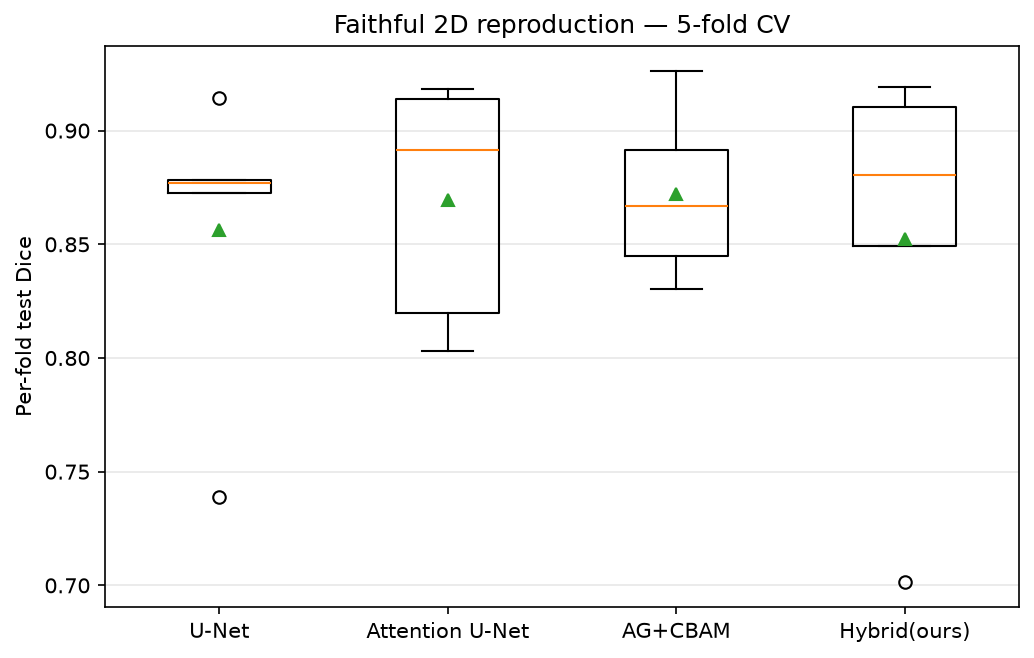

In [3]:
display(Image(filename=fig("results_faithful2d/fig_kfold_box.png"), width=620))

**Full-data takeaway.** With abundant data on this (relatively easy) organ, adding channel
attention gives **no reliable improvement** over the paper's model: our Hybrid is *worse*
(p<0.001) and the CBAM edge is within the fold-to-fold std (p=0.27). The four models overlap
almost entirely (figure above).

## 3. Low-data results (n = 8 training patients, 8 seeds)
Motivated by the paper's claim that attention helps most when data is scarce, we retrained each
variant on only 8 patients (fixed test set, 8 seeds; ~2,000 paired test slices).

In [4]:
low = pd.DataFrame({
    "Variant": ["U-Net", "Attention U-Net (paper)", "AG + CBAM", "Hybrid (ours)"],
    "Dice (n=8, 8 seeds)": [0.784, 0.793, 0.877, 0.824],
    "vs paper's model": ["-", "baseline", "+0.084 (p<0.0001)", "+0.031 (p<0.0001)"],
})
display(low)
print("Paired Wilcoxon vs the paper's model (Attention U-Net):")
print("  AG+CBAM  vs Attention U-Net:  +0.084 Dice, p<0.0001  -> SIGNIFICANT improvement")
print("  Hybrid   vs Attention U-Net:  +0.031 Dice, p<0.0001  -> SIGNIFICANT improvement (our idea wins here)")

,Variant,"Dice (n=8, 8 seeds)",vs paper's model
0,U-Net,0.784,-
1,Attention U-Net (paper),0.793,baseline
2,AG + CBAM,0.877,+0.084 (p<0.0001)
3,Hybrid (ours),0.824,+0.031 (p<0.0001)


Paired Wilcoxon vs the paper's model (Attention U-Net):
  AG+CBAM  vs Attention U-Net:  +0.084 Dice, p<0.0001  -> SIGNIFICANT improvement
  Hybrid   vs Attention U-Net:  +0.031 Dice, p<0.0001  -> SIGNIFICANT improvement (our idea wins here)


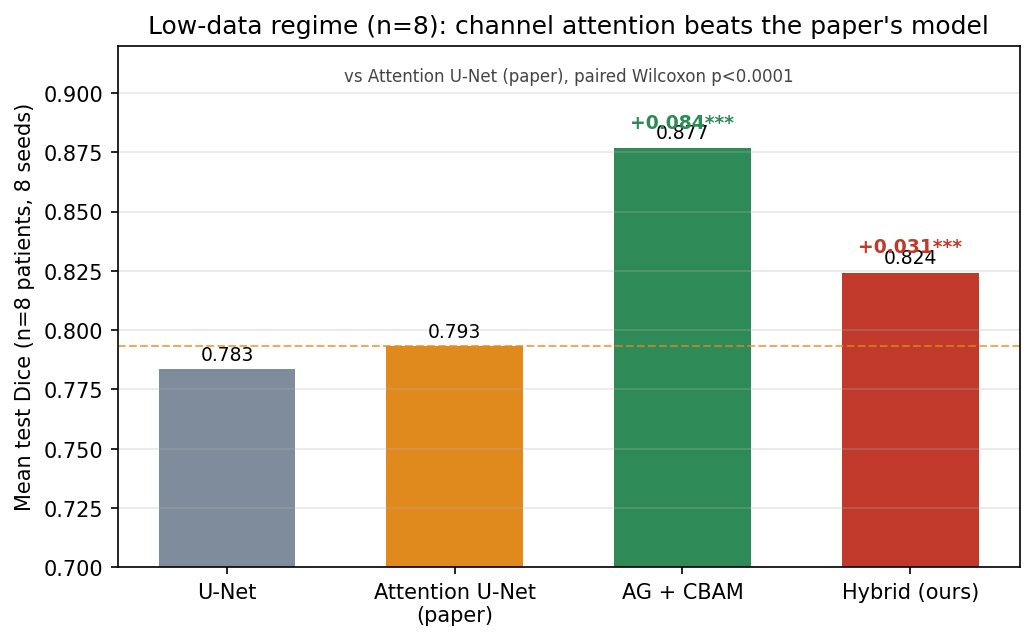

In [5]:
display(Image(filename=fig("results_lowdata_focus/fig_lowdata_n8.png"), width=620))

**Low-data takeaway.** With only 8 patients, **both** channel-attention designs — including
our Hybrid, which lost at full data — **significantly beat the paper's Attention U-Net**
(Hybrid +0.031, CBAM +0.084 Dice, p<0.0001). This confirms and extends the paper's own thesis:
attention's benefit concentrates when data is scarce, and *channel* selection adds value on top
of spatial attention precisely in that regime.

### Qualitative comparison (low-data predictions)
Prediction (red) vs. ground-truth contour (blue) on fixed test slices, low-data (n=8) models.

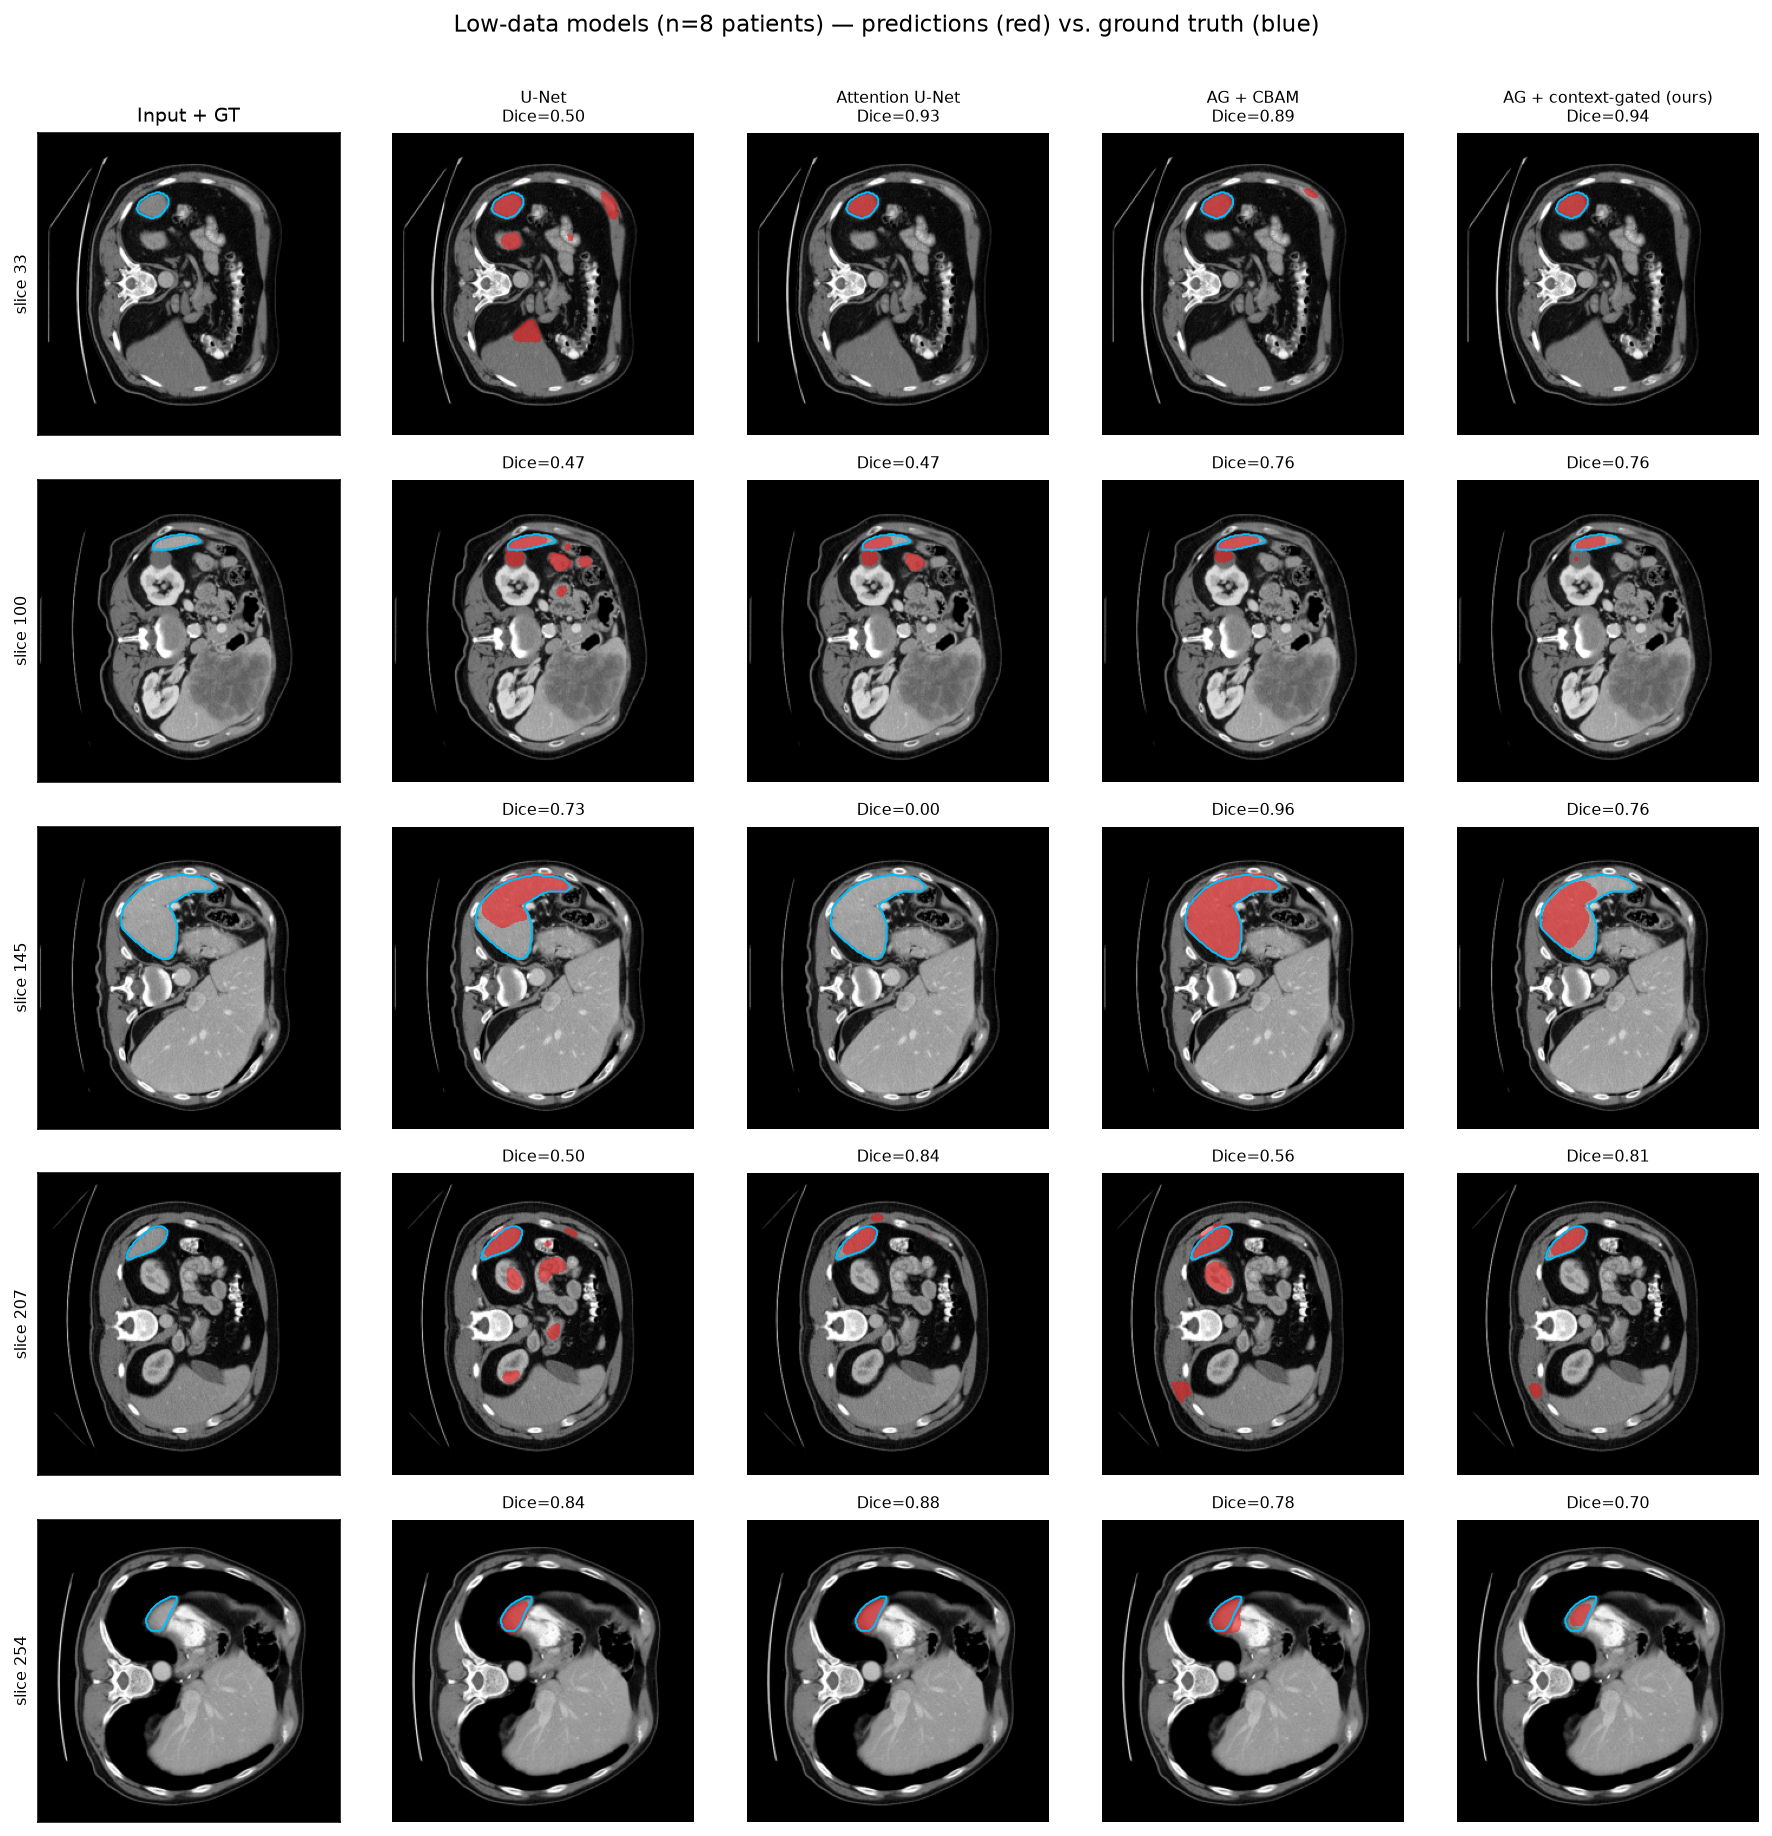

In [6]:
display(Image(filename=fig("results_grids/fig_grid_lowdata.png"), width=820))

At n=8 the U-Net and the paper's Attention U-Net show frequent misses and stray false
positives (the Attention U-Net even scores 0.00 on one slice), while AG+CBAM and our Hybrid
track the spleen much more cleanly. At full data all four look nearly identical.

## 4. Conclusion
- **Full data:** our extension does not improve the paper's model (Hybrid worse; CBAM within noise).
- **Low data (n=8):** both channel-attention variants, **including our Hybrid, significantly
  improve the paper's model** (p<0.0001).
- **Interpretation:** channel selection helps on top of spatial attention specifically when data
  is scarce — consistent with, and extending, the paper's finding.

**Limitations:** 2D proof-of-concept on one organ; Dice+Focal loss needed for 2D stability; higher
variance for gated variants; fixed-test (not k-fold) low-data protocol; CBAM > our Hybrid. We
emphasize effect sizes over p-values (per-slice samples from one patient are correlated).

## 5. Reproduce (run on a GPU — not executed here)
```bash
# data
python -m src.data --root ./decathlon_data --out ./slices_2d_256 --image-size 256
# full-data 5-fold study
python -m faithful_2d.train --slice-dir ./slices_2d_256 --k 5 --epochs 60
python -m faithful_2d.evaluate --slice-dir ./slices_2d_256 --results ./results_faithful2d/results_faithful2d.json --out-dir ./results_faithful2d
# low-data n=8 study (8 seeds + significance)
python -m faithful_2d.lowdata_focus --slice-dir ./slices_2d_256 --size 8 --n-seeds 8 --epochs 60
# qualitative grids
python -m faithful_2d.visualize_grid --setting lowdata --slice-dir ./slices_2d_256
```
Model & training code: `faithful_2d/` (model.py, train.py, lowdata_focus.py, evaluate.py) and
`src/layers.py` (the attention-gate variants).